## Assignment 5: Generative Adversarial Network on MNIST

In this assignment, we train a Generative Adversarial Network (GAN) to generate handwritten digit images from the MNIST dataset. The GAN consists of two neural networks trained adversarially:

- a generator, which takes random noise as input and tries to produce realistic handwritten digits,
- a discriminator, which tries to distinguish real MNIST images from fake images produced by the generator.

The goal is to make the generator learn the data distribution well enough that the generated images become increasingly realistic during training.

In this notebook, we:
- load and normalize the MNIST dataset,
- define a generator and discriminator,
- train both models in alternating steps,
- monitor the discriminator and generator losses,
- log generated and real images with TensorBoard,
- visualize how the generated digit quality improves over training.

In [13]:
import os
import matplotlib.pyplot as plt
import time
import torchvision
# For image transforms
from torchvision import transforms
# For DATA SET
import torchvision.datasets as datasets
# For Pytorch methods
import torch
import torch.nn as nn
# For Optimizer
import torch.optim as optim
# FOR DATA LOADER
from torch.utils.data import DataLoader
# FOR TENSOR BOARD VISUALIZATION
from torch.utils.tensorboard import SummaryWriter # to print to tensorboard

In [14]:
# Hyperparameters
lr = 2e-4
batchSize = 128
image_dimension = 28 * 28 * 1
latent_dimension = 100
numEpochs = 100
logStep = 1000

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))

# we define a tranform that converts the image to tensor and normalizes it with mean and std of 0.5
# which will convert the image range from [0, 1] to [-1, 1]
myTransforms = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5,), (0.5,))])

Using device: cuda
CUDA device: NVIDIA GeForce RTX 3060


In [15]:
# the MNIST dataset is available through torchvision.datasets
print("loading MNIST digits dataset")
dataset = datasets.MNIST(root="dataset/", transform=myTransforms, download=True)
# let's create a dataloader to load the data in batches
loader = DataLoader(dataset, batch_size=batchSize, shuffle=True, num_workers=4, pin_memory=True)

loading MNIST digits dataset


In [16]:
class Generator(nn.Module):
    """
    Generator Model
    """
    def __init__(self):
        super().__init__()
        self.gen = nn.Sequential(
            # Project latent space
            nn.Linear(latent_dimension, 64 * 7 * 7),
            nn.ReLU(True),

            # Reshape
            nn.Unflatten(1, (64, 7, 7)),

            # Upsamle convolutional layers
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            
            nn.Tanh(),  # It is helpful to use the tanh activation function to force the ouput into the [-1,1] range that our normalized images have.
        )

    def forward(self, x):
        return self.gen(x)



class Discriminator(nn.Module):
    """
    Discriminator Model
    """
    def __init__(self):
        super().__init__()
        self.disc = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),   # 28 -> 14
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 14 -> 7
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.disc(x)


In [17]:
# initialize networks and optimizers
discriminator = Discriminator().to(device)
generator = Generator().to(device)
opt_discriminator = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
opt_generator = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))

# This is a binary classification task, so we use Binary Cross Entropy Loss
criterion = nn.BCELoss()

# TensorBoard writers
writerFake = SummaryWriter("runs/GAN_MNIST/fake")
writerReal = SummaryWriter("runs/GAN_MNIST/real")

# Fixed noise for consistent monitoring
fixed_noise = torch.randn(32, latent_dimension).to(device)

# Epochs at which we save fixed-noise samples
saved_epochs = [1, 10, 25, 50, 100]

# Folder for saved images and weights
os.makedirs("gan_outputs", exist_ok=True)
os.makedirs("gan_outputs/fixed_noise_samples", exist_ok=True)

In [18]:
# Training Loop
step = 0
training_start_time = time.time()
print("Started Training and visualization...")

generator.train()
discriminator.train()

for epoch in range(numEpochs):
    epoch_start_time = time.time()

    # loop over batches
    print()
    for batch_idx, (real, _) in enumerate(loader):
        # First we train the discriminator on real images vs. generated images

        # Get the real images
        real = real.to(device, non_blocking=True)
        batch_size = real.shape[0]

        # Step 1) generate fake images
        noise = torch.randn(batch_size, latent_dimension).to(device, non_blocking=True)
        fake = generator(noise)

        # Step 2) Train Discriminator:
        # - predict the discriminator output for real images
        # - real images are labeled as 1
        # - calculate the loss for real images
        discriminator_real = discriminator(real).view(-1)
        loss_discriminator_real = criterion(discriminator_real, torch.ones_like(discriminator_real))

        # - predict the discriminator output for fake images
        # - fake images are labeled as 0
        # - calculate the loss for fake images
        discriminator_fake = discriminator(fake.detach()).view(-1)
        loss_discriminator_fake = criterion(discriminator_fake, torch.zeros_like(discriminator_fake))

        # - average the loss for real and fake images
        loss_discriminator = (loss_discriminator_real + loss_discriminator_fake) / 2

        # - now update the weights of the discriminator by backpropagating the loss through the discriminator
        # the generator is not updated in this step
        opt_discriminator.zero_grad()
        loss_discriminator.backward()
        opt_discriminator.step()

        # Train Generator:
        # Now train the generator by generating fake images and passing them through the discriminator
        # You can do a little trick and modify the original objective function of
        # "minimizing the probability of the discriminator predicting the fake images as fake"
        # to "maximizing the probability of the discriminator predicting the fake images as real"
        # this leads to a faster training of the generator when it does not represent the real data well
        # this is a common trick in GANs
        # for more information see section 17.1.2 of the book Deep Learning by Bishop and Bishop

        # - pass the fake images through the discriminator
        output = discriminator(fake).view(-1)

        # - calculate the loss (labels set to 1)
        loss_generator = criterion(output, torch.ones_like(output))

        # - update the weights of the generator
        opt_generator.zero_grad()
        loss_generator.backward()
        opt_generator.step()

        # print the progress
        print(
            f"\rEpoch [{epoch+1}/{numEpochs}] Batch {batch_idx}/{len(loader)} "
            f"| Loss discriminator: {loss_discriminator:.4f}, loss generator: {loss_generator:.4f}",
            end=""
        )

        # Log the losses and example images to tensorboard
        if batch_idx % logStep == 0:
            with torch.no_grad():
                # Generate noise via Generator, we always use the same noise to see the progression
                fake_fixed = generator(fixed_noise)
                # Get real data
                data = real[:32]
                # make grid of pictures and add to tensorboard
                imgGridFake = torchvision.utils.make_grid(fake_fixed, normalize=True, nrow=8)
                imgGridReal = torchvision.utils.make_grid(data, normalize=True, nrow=8)

                writerFake.add_image("MNIST Fake Images", imgGridFake, global_step=step)
                writerReal.add_image("MNIST Real Images", imgGridReal, global_step=step)
                writerFake.add_scalar("Loss Discriminator", loss_discriminator.item(), global_step=step)
                writerFake.add_scalar("Loss Generator", loss_generator.item(), global_step=step)

        step += 1

    epoch_time = time.time() - epoch_start_time
    total_time = time.time() - training_start_time
    print(f"\nEpoch {epoch+1}/{numEpochs} finished in {epoch_time:.2f} s | total elapsed: {total_time:.2f} s")

    # Save fixed-noise sample images at selected epochs
    if (epoch + 1) in saved_epochs:
        generator.eval()
        with torch.no_grad():
            fake_fixed = generator(fixed_noise).cpu()
            imgGridFake = torchvision.utils.make_grid(fake_fixed, normalize=True, nrow=8)

            plt.figure(figsize=(8, 8))
            plt.imshow(imgGridFake.permute(1, 2, 0), cmap="gray")
            plt.axis("off")
            plt.title(f"Generated MNIST digits at epoch {epoch+1}")
            plt.savefig(f"gan_outputs/fixed_noise_samples/epoch_{epoch+1}.png", bbox_inches="tight")
            plt.close()
        generator.train()

# Save final weights
torch.save(generator.state_dict(), "gan_outputs/generator_mnist.pth")
torch.save(discriminator.state_dict(), "gan_outputs/discriminator_mnist.pth")

writerFake.close()
writerReal.close()

Started Training and visualization...

Epoch [1/100] Batch 468/469 | Loss discriminator: 0.2441, loss generator: 1.3261
Epoch 1/100 finished in 7.13 s | total elapsed: 7.13 s

Epoch [2/100] Batch 468/469 | Loss discriminator: 0.1216, loss generator: 2.2404
Epoch 2/100 finished in 7.86 s | total elapsed: 15.08 s

Epoch [3/100] Batch 468/469 | Loss discriminator: 0.1404, loss generator: 1.8421
Epoch 3/100 finished in 6.48 s | total elapsed: 21.55 s

Epoch [4/100] Batch 468/469 | Loss discriminator: 0.1418, loss generator: 2.2004
Epoch 4/100 finished in 6.45 s | total elapsed: 28.00 s

Epoch [5/100] Batch 468/469 | Loss discriminator: 0.1955, loss generator: 1.8383
Epoch 5/100 finished in 6.49 s | total elapsed: 34.49 s

Epoch [6/100] Batch 468/469 | Loss discriminator: 0.2165, loss generator: 3.0278
Epoch 6/100 finished in 6.58 s | total elapsed: 41.06 s

Epoch [7/100] Batch 468/469 | Loss discriminator: 0.1270, loss generator: 2.9220
Epoch 7/100 finished in 6.48 s | total elapsed: 47.54

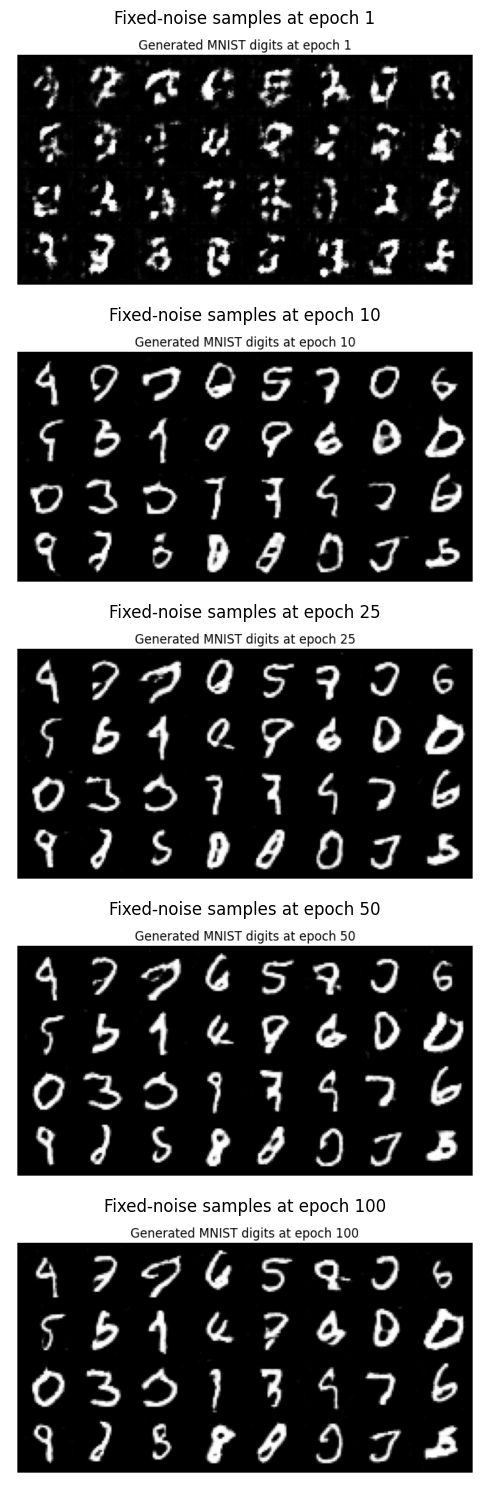

In [19]:
# Show saved fixed-noise generations across training
epochs_to_show = [e for e in saved_epochs if os.path.exists(f"gan_outputs/fixed_noise_samples/epoch_{e}.png")]

fig, axes = plt.subplots(len(epochs_to_show), 1, figsize=(10, 3 * len(epochs_to_show)))

if len(epochs_to_show) == 1:
    axes = [axes]

for ax, e in zip(axes, epochs_to_show):
    img = plt.imread(f"gan_outputs/fixed_noise_samples/epoch_{e}.png")
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"Fixed-noise samples at epoch {e}")

plt.tight_layout()
plt.show()

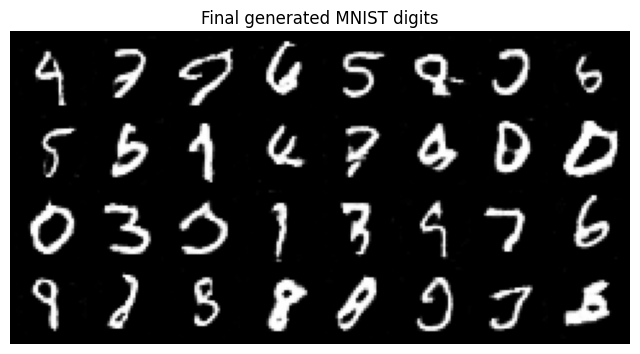

In [20]:
# Show final generated images in the notebook
generator.eval()

with torch.no_grad():
    generated = generator(fixed_noise).cpu()

imgGrid = torchvision.utils.make_grid(generated, nrow=8, normalize=True)

plt.figure(figsize=(8, 8))
plt.imshow(imgGrid.permute(1, 2, 0), cmap="gray")
plt.axis("off")
plt.title("Final generated MNIST digits")
plt.show()

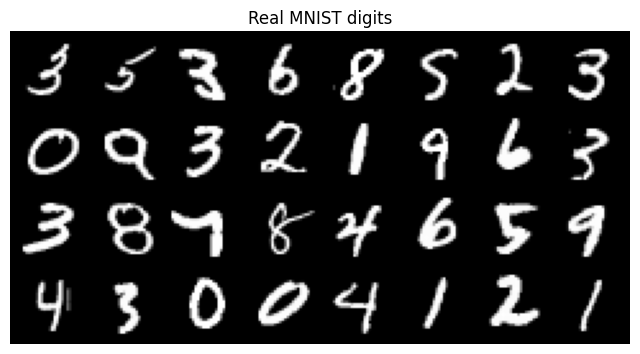

In [21]:
# Show a batch of real images for comparison
real_batch, _ = next(iter(loader))
real_batch = real_batch[:32]

imgGridReal = torchvision.utils.make_grid(real_batch, nrow=8, normalize=True)

plt.figure(figsize=(8, 8))
plt.imshow(imgGridReal.permute(1, 2, 0), cmap="gray")
plt.axis("off")
plt.title("Real MNIST digits")
plt.show()